# Ejercicios - Módulo 3

In [1]:
import pandas as pd
import numpy as np

## Ejercicio 1: Preparación de datos

Usando el dataset de precios de autos:

**1.** Carga el dataset y muestra las primeras 5 filas

In [2]:
import os

url = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'
local_path = 'data.csv'

if os.path.exists(local_path):
    df = pd.read_csv(local_path)
else:
    import urllib.request
    urllib.request.urlretrieve(url, local_path)
    df = pd.read_csv(local_path)

df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


Este dataset contiene información detallada sobre vehículos con las siguientes características:

**Características del Vehículo:**

- **Make** (Marca): BMW, Audi, Mercedes-Benz, Toyota, etc.
- **Model**: Modelo específico del vehículo
- **Year**: Año de fabricación (1990-2017)
- **Engine HP**: Potencia del motor en caballos de fuerza
- **Engine Cylinders**: Número de cilindros del motor
- **Engine Fuel Type**: Tipo de combustible (regular unleaded, premium unleaded, etc.)

**Especificaciones Técnicas:**

- **Transmission Type**: Tipo de transmisión (MANUAL, AUTOMATIC, AUTOMATED_MANUAL)
- **Driven_Wheels**: Tracción (rear wheel drive, front wheel drive, all wheel drive, four wheel drive)
- **Number of Doors**: Número de puertas
- **Vehicle Size**: Tamaño del vehículo (Compact, Midsize, Large)
- **Vehicle Style**: Estilo del vehículo (Sedan, Coupe, Convertible, SUV, etc.)

**Eficiencia y Popularidad:**

- **highway MPG**: Millas por galón en carretera
- **city mpg**: Millas por galón en ciudad
- **Popularity**: Índice de popularidad del vehículo
- **MSRP**: Precio de venta sugerido por el fabricante (nuestra **variable objetivo**)

**2.** Identifica columnas con valores nulos y decide cómo tratarlos

Revisamos las columnas y sus valores. Convertimos los nombres de las columnas y los datos tipo string en minúsculas y reemplazamos los espacios con guión bajo.

In [3]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

for col in df.dtypes[df.dtypes == 'str'].index:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [4]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500


In [5]:
df.shape

(11914, 16)

Revisamos qué columnas tienen datos nulos.

In [6]:
df.isnull().sum()


make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

Eliminamos los datos de la columna market_cateogry.

In [7]:
df.drop('market_category', axis=1, inplace=True)

Revisamos qué datos de engine_fuel_type son cero.

In [8]:
df[df['engine_fuel_type'].isnull()]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11321,suzuki,verona,2004,NaN,155.0,6.0,automatic,front_wheel_drive,4.0,midsize,sedan,25,17,481,17199
11322,suzuki,verona,2004,NaN,155.0,6.0,automatic,front_wheel_drive,4.0,midsize,sedan,25,17,481,20199
11323,suzuki,verona,2004,NaN,155.0,6.0,automatic,front_wheel_drive,4.0,midsize,sedan,25,17,481,18499


Buscamos datos de la misma make, model y year para ver si podemos imputar

In [9]:
df[(df['make'] == 'suzuki') & (df['model'] == 'verona') & (df['year'] == 2004)]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
11321,suzuki,verona,2004,NaN,155.0,6.0,automatic,front_wheel_drive,4.0,midsize,sedan,25,17,481,17199
11322,suzuki,verona,2004,NaN,155.0,6.0,automatic,front_wheel_drive,4.0,midsize,sedan,25,17,481,20199
11323,suzuki,verona,2004,NaN,155.0,6.0,automatic,front_wheel_drive,4.0,midsize,sedan,25,17,481,18499


Como no hay más datos con las mismas características los eliminamos.

In [10]:
df = df[~df['engine_fuel_type'].isnull()]
df.isnull().sum()

make                  0
model                 0
year                  0
engine_fuel_type      0
engine_hp            69
engine_cylinders     30
transmission_type     0
driven_wheels         0
number_of_doors       6
vehicle_size          0
vehicle_style         0
highway_mpg           0
city_mpg              0
popularity            0
msrp                  0
dtype: int64

Ahora revisamos engine_hp.

In [11]:
df[df['engine_hp'].isnull()]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
539,fiat,500e,2015,electric,NaN,0.0,direct_drive,front_wheel_drive,2.0,compact,2dr_hatchback,108,122,819,31800
540,fiat,500e,2016,electric,NaN,0.0,direct_drive,front_wheel_drive,2.0,compact,2dr_hatchback,103,121,819,31800
541,fiat,500e,2017,electric,NaN,0.0,direct_drive,front_wheel_drive,2.0,compact,2dr_hatchback,103,121,819,31800
2905,lincoln,continental,2017,premium_unleaded_(recommended),NaN,6.0,automatic,all_wheel_drive,4.0,large,sedan,25,17,61,55915
2906,lincoln,continental,2017,premium_unleaded_(recommended),NaN,6.0,automatic,front_wheel_drive,4.0,large,sedan,27,18,61,62915
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9850,kia,soul_ev,2015,electric,NaN,0.0,direct_drive,front_wheel_drive,4.0,compact,wagon,92,120,1720,35700
9851,kia,soul_ev,2015,electric,NaN,0.0,direct_drive,front_wheel_drive,4.0,compact,wagon,92,120,1720,33700
9852,kia,soul_ev,2016,electric,NaN,0.0,direct_drive,front_wheel_drive,4.0,compact,wagon,92,120,1720,33950
9853,kia,soul_ev,2016,electric,NaN,0.0,direct_drive,front_wheel_drive,4.0,compact,wagon,92,120,1720,31950


In [12]:
#Extrae los make, model y year de los engine hp que son nulo. Busca los valores de make, model y year en el dataset para ver si existe algun dato que se repite y que tenga un valor no nulo en engine hp o el promedio si hay más de un valor. Si no existe, elimina la columna
df_null_hp = df[df['engine_hp'].isnull()]
for index, row in df_null_hp.iterrows():
    make = row['make']
    model = row['model']
    year = row['year']
    
    # Busca filas con el mismo make, model y year
    similar_rows = df[(df['make'] == make) & (df['model'] == model) & (df['year'] == year) & (~df['engine_hp'].isnull())]
    
    if not similar_rows.empty:
        print(f"Filas similares encontradas para {make} {model} {year}:")
        print(similar_rows[['make', 'model', 'year', 'engine_hp']])
        # Si hay filas similares con engine_hp no nulo, calcula el promedio
        avg_hp = similar_rows['engine_hp'].mean()
        df.at[index, 'engine_hp'] = avg_hp
    else:
        # Si no hay filas similares, elimina la fila actual
        print(f"No se encontraron filas similares para {make} {model} {year}. Eliminando la fila. \n")
        df.drop(index, inplace=True)

No se encontraron filas similares para fiat 500e 2015. Eliminando la fila. 

No se encontraron filas similares para fiat 500e 2016. Eliminando la fila. 

No se encontraron filas similares para fiat 500e 2017. Eliminando la fila. 

Filas similares encontradas para lincoln continental 2017:
         make        model  year  engine_hp
2902  lincoln  continental  2017      305.0
2903  lincoln  continental  2017      305.0
2904  lincoln  continental  2017      305.0
2909  lincoln  continental  2017      305.0
Filas similares encontradas para lincoln continental 2017:
         make        model  year  engine_hp
2902  lincoln  continental  2017      305.0
2903  lincoln  continental  2017      305.0
2904  lincoln  continental  2017      305.0
2905  lincoln  continental  2017      305.0
2909  lincoln  continental  2017      305.0
Filas similares encontradas para lincoln continental 2017:
         make        model  year  engine_hp
2902  lincoln  continental  2017      305.0
2903  lincoln  conti

Validamos nuevamente los nulos.

In [13]:
df.isnull().sum()

make                  0
model                 0
year                  0
engine_fuel_type      0
engine_hp             0
engine_cylinders     29
transmission_type     0
driven_wheels         0
number_of_doors       1
vehicle_size          0
vehicle_style         0
highway_mpg           0
city_mpg              0
popularity            0
msrp                  0
dtype: int64

Ahora realizamos el mismo proceso con engine_cylinders

In [14]:
df[df['engine_cylinders'].isnull()]
df_null_cylinders = df[df['engine_cylinders'].isnull()]
for index, row in df_null_cylinders.iterrows():
    make = row['make']
    model = row['model']
    year = row['year']
    
    # Busca filas con el mismo make, model y year
    similar_rows = df[(df['make'] == make) & (df['model'] == model) & (df['year'] == year) & (~df['engine_cylinders'].isnull())]
    
    if not similar_rows.empty:
        print(f"Filas similares encontradas para {make} {model} {year}:")
        print(similar_rows[['make', 'model', 'year', 'engine_cylinders']])
        # Si hay filas similares con engine_cylinders no nulo, calcula el promedio
        avg_cylinders = similar_rows['engine_cylinders'].mean()
        df.at[index, 'engine_cylinders'] = avg_cylinders
    else:
        # Si no hay filas similares, elimina la fila actual
        print(f"No se encontraron filas similares para {make} {model} {year}. Eliminando la fila. \n\n")
        df.drop(index, inplace=True)

No se encontraron filas similares para chevrolet bolt_ev 2017. Eliminando la fila. 


No se encontraron filas similares para chevrolet bolt_ev 2017. Eliminando la fila. 


No se encontraron filas similares para volkswagen e-golf 2015. Eliminando la fila. 


No se encontraron filas similares para volkswagen e-golf 2015. Eliminando la fila. 


No se encontraron filas similares para volkswagen e-golf 2016. Eliminando la fila. 


No se encontraron filas similares para volkswagen e-golf 2016. Eliminando la fila. 


No se encontraron filas similares para mitsubishi i-miev 2016. Eliminando la fila. 


No se encontraron filas similares para mitsubishi i-miev 2017. Eliminando la fila. 


No se encontraron filas similares para toyota rav4_ev 2012. Eliminando la fila. 


No se encontraron filas similares para mazda rx-7 1993. Eliminando la fila. 


No se encontraron filas similares para mazda rx-7 1994. Eliminando la fila. 


No se encontraron filas similares para mazda rx-7 1995. Eliminando la f

In [15]:
df.isnull().sum()

make                 0
model                0
year                 0
engine_fuel_type     0
engine_hp            0
engine_cylinders     0
transmission_type    0
driven_wheels        0
number_of_doors      1
vehicle_size         0
vehicle_style        0
highway_mpg          0
city_mpg             0
popularity           0
msrp                 0
dtype: int64

Finalmente, revisamos el dato nulo de number_of_doors

In [16]:
#Ahora repetimos el proceso para la columna number_of_doors
df[df['number_of_doors'].isnull()]
df_null_doors = df[df['number_of_doors'].isnull()]
for index, row in df_null_doors.iterrows():
    make = row['make']
    model = row['model']
    year = row['year']
    
    # Busca filas con el mismo make, model y year
    similar_rows = df[(df['make'] == make) & (df['model'] == model) & (df['year'] == year) & (~df['number_of_doors'].isnull())]
    
    if not similar_rows.empty:
        print(f"Filas similares encontradas para {make} {model} {year}:")
        print(similar_rows[['make', 'model', 'year', 'number_of_doors']])
        # Si hay filas similares con number_of_doors no nulo, calcula el promedio
        avg_doors = similar_rows['number_of_doors'].mean()
        df.at[index, 'number_of_doors'] = avg_doors
    else:
        # Si no hay filas similares, elimina la fila actual
        print(f"No se encontraron filas similares para {make} {model} {year}. Eliminando la fila. \n\n")
        df.drop(index, inplace=True)

No se encontraron filas similares para ferrari ff 2013. Eliminando la fila. 




In [17]:
df.isnull().sum()

make                 0
model                0
year                 0
engine_fuel_type     0
engine_hp            0
engine_cylinders     0
transmission_type    0
driven_wheels        0
number_of_doors      0
vehicle_size         0
vehicle_style        0
highway_mpg          0
city_mpg             0
popularity           0
msrp                 0
dtype: int64

In [18]:
df.shape

(11834, 15)

Finalmente, después de la limpieza, pasamos de tener 11914 datos y 16 columnas a tener 11834 datos y 15 columnas.

**3.** Aplica transformación log al target (precio)

In [19]:
df['msrp'] = np.log1p(df['msrp'])

**4.** Divide en train (60%), validación (20%) y test (20%)

In [20]:
#Divide en train (60%), validación (20%) y test (20%)
from sklearn.model_selection import train_test_split
train_val, test = train_test_split(df, test_size=0.2, random_state=42)
train, val = train_test_split(train_val, test_size=0.25, random_state=42) #Se pone test_size en 0.25, porque el 25% de 80% es igual al 20% del total, lo que garantiza que el conjunto de validación tenga el mismo tamaño que el conjunto de prueba.
train.shape, val.shape, test.shape

((7100, 15), (2367, 15), (2367, 15))

## Ejercicio 2: Regresión lineal

**1.** Entrena un modelo de regresión lineal con solo 2 features: `year` y `engine_hp`

Importamos las librerías.

In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

Seleccionamos las features y el target

In [22]:
X_train = train[['year', 'engine_hp']]
y_train = train['msrp']
X_val = val[['year', 'engine_hp']]
y_val = val['msrp']
X_test = test[['year', 'engine_hp']]
y_test = test['msrp']

Entrenamos el modelo

In [23]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


**2.** Calcula el RMSE en validación

Hacemos la predicción y calculamos el error cuadrático medio

In [24]:
y_pred_train = model.predict(X_train)
y_pred_val = model.predict(X_val)
y_pred_test = model.predict(X_test)

rmse_train = root_mean_squared_error(y_train, y_pred_train)
rmse_val = root_mean_squared_error(y_val, y_pred_val)
rmse_test = root_mean_squared_error(y_test, y_pred_test)

print(f"RMSE Train: {rmse_train}")
print(f"RMSE Validation: {rmse_val}")
print(f"RMSE Test: {rmse_test}")

RMSE Train: 0.5179002725754648
RMSE Validation: 0.5174356509037223
RMSE Test: 0.5194245540693766


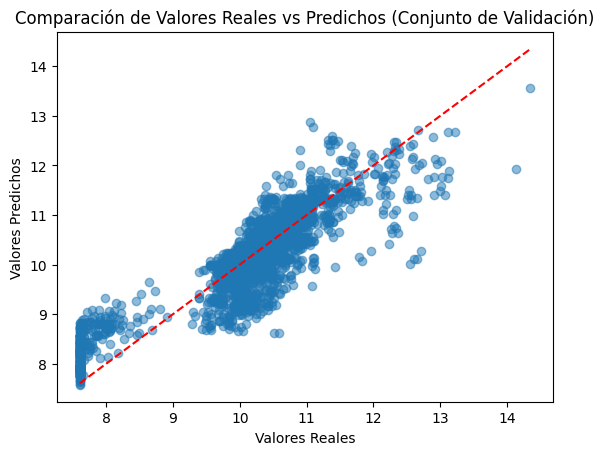

In [ ]:
#Grafica los valores reales vs los predichos para el conjunto de validación y sobre los datos la regresion lineal
import matplotlib.pyplot as plt
plt.scatter(y_val, y_pred_val, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')  # Línea de referencia para la predicción perfecta
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title('Comparación de Valores Reales vs Predichos (Conjunto de Validación)')
plt.show()

**3.** Agrega 3 features más y re-entrena. ¿Mejoró el RMSE?

In [26]:
#Agrega 3 features más y re-entrena. ¿Mejoró el RMSE?
X_train2 = train[['year', 'engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg']]
y_train2 = train['msrp']
X_val2 = val[['year', 'engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg']]
y_val2 = val['msrp']
X_test2 = test[['year', 'engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg']]
y_test2 = test['msrp']

model2 = LinearRegression()
model2.fit(X_train2, y_train2)

y_pred_train2 = model2.predict(X_train2)
y_pred_val2 = model2.predict(X_val2)
y_pred_test2 = model2.predict(X_test2)

rmse_train2 = root_mean_squared_error(y_train2, y_pred_train2)
rmse_val2 = root_mean_squared_error(y_val2, y_pred_val2)
rmse_test2 = root_mean_squared_error(y_test2, y_pred_test)

print(f"RMSE Train: {rmse_train2}")
print(f"RMSE Validation: {rmse_val2}")
print(f"RMSE Test: {rmse_test2}")

RMSE Train: 0.5149355013963323
RMSE Validation: 0.5133207640585632
RMSE Test: 0.5194245540693766


**4.** Interpreta los 3 pesos más grandes del modelo

In [27]:
features = ['year', 'engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg']
coef_df = pd.DataFrame({
    'feature': features,
    'weight': model2.coef_
}).sort_values('weight', key=abs, ascending=False)

print("Pesos del modelo (ordenados por magnitud):")
print(coef_df.to_string(index=False))
print(f"\nIntercepto: {model2.intercept_:.6f}")
print("\nTop 3 pesos más grandes (en valor absoluto):")
print(coef_df.head(3).to_string(index=False))

Pesos del modelo (ordenados por magnitud):
         feature    weight
            year  0.093141
engine_cylinders  0.059237
 number_of_doors -0.017053
       engine_hp  0.003869
     highway_mpg  0.000149

Intercepto: -178.377646

Top 3 pesos más grandes (en valor absoluto):
         feature    weight
            year  0.093141
engine_cylinders  0.059237
 number_of_doors -0.017053


Recordar que el target es `log1p(msrp)`, por lo que cada coeficiente representa el cambio en el logaritmo del precio por cada unidad de aumento en la variable.

`year` — peso: 0.093141 (positivo)

El peso más alto del modelo. Cada año adicional de fabricación incrementa el log-precio en 0.093 unidades. Autos más recientes incorporan tecnología avanzada, mejor seguridad y mayor demanda, lo que se traduce en precios más altos.


`engine_cylinders` — peso: 0.059237 (positivo)

Más cilindros implica un motor más grande y potente, característico de vehículos de lujo o de alto rendimiento. El modelo captura que esta variable está fuertemente asociada a precios elevados.

 `number_of_doors` — peso: -0.017053 (negativo)

Vehículos con más puertas (sedanes familiares, minivans) tienden a ser más accesibles en precio que los de 2 puertas (deportivos, coupés), que suelen ser modelos premium. Por eso el coeficiente es negativo.

El modelo asigna mayor importancia al año y al número de cilindros como predictores positivos del precio, y al número de puertas como predictor negativo. Curiosamente, `engine_hp` y `highway_mpg` tienen pesos muy bajos (0.003869 y 0.000149), lo que sugiere que en presencia de `engine_cylinders` y `year`, la potencia en HP aporta poca información adicional al modelo.

## Ejercicio 3: Feature engineering

**1.** Crea la variable `antiguedad = 2024 - year`

In [28]:
df['antiguedad'] = 2024 - df['year']

**2.** Aplica One-Hot Encoding a la columna `make` (marca)

In [29]:
df = pd.get_dummies(df, columns=['make'], drop_first=True)
df.head()

,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,vehicle_size,vehicle_style,...,make_porsche,make_rolls-royce,make_saab,make_scion,make_spyker,make_subaru,make_suzuki,make_toyota,make_volkswagen,make_volvo
0,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,compact,coupe,...,False,False,False,False,False,False,False,False,False,False
1,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,compact,convertible,...,False,False,False,False,False,False,False,False,False,False
2,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,compact,coupe,...,False,False,False,False,False,False,False,False,False,False
3,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,compact,coupe,...,False,False,False,False,False,False,False,False,False,False
4,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,compact,convertible,...,False,False,False,False,False,False,False,False,False,False


**3.** Entrena un modelo con todas las features (numéricas + encoded)

In [30]:
# Dividimos con el df actualizado (ya tiene antiguedad + make encoded)
train_val3, test3 = train_test_split(df, test_size=0.2, random_state=42)
train3, val3 = train_test_split(train_val3, test_size=0.25, random_state=42)

# Features del modelo anterior + columnas make one hot encoding
base_features = ['year', 'engine_hp', 'engine_cylinders', 'number_of_doors', 'highway_mpg']
make_cols = [col for col in df.columns if col.startswith('make_')]
feature_cols = base_features + make_cols

X_train3 = train3[feature_cols]
y_train3 = train3['msrp']
X_val3 = val3[feature_cols]
y_val3 = val3['msrp']

model3 = LinearRegression()
model3.fit(X_train3, y_train3)

rmse_train3 = root_mean_squared_error(y_train3, model3.predict(X_train3))
rmse_val3 = root_mean_squared_error(y_val3, model3.predict(X_val3))

print(f"Features base: {len(base_features)} | Features make one hot encoding: {len(make_cols)} | Total: {len(feature_cols)}")
print(f"RMSE Train: {rmse_train3:.4f}")
print(f"RMSE Validación: {rmse_val3:.4f}")

Features base: 5 | Features make one hot encoding: 46 | Total: 51
RMSE Train: 0.4482
RMSE Validación: 0.4444


**4.** Compara el RMSE con el modelo del ejercicio 2



In [31]:
print("Comparación de RMSE en validación:")
print(f"Modelo Ej.2 (5 features): {rmse_val2:.4f}")
print(f"Modelo Ej.3 (5 features + make one hot encoding): {rmse_val3:.4f}")
mejora = rmse_val2 - rmse_val3
print(f"Mejora absoluta: {mejora:.4f}")
print(f"Mejora relativa: {mejora / rmse_val2 * 100:.1f}%")

Comparación de RMSE en validación:
Modelo Ej.2 (5 features): 0.5133
Modelo Ej.3 (5 features + make one hot encoding): 0.4444
Mejora absoluta: 0.0689
Mejora relativa: 13.4%


Al incorporar el One-Hot Encoding de la marca (`make`), el modelo pasó de un RMSE de validación de 0.5133 a 0.4444, una mejora absoluta de 0.0689 puntos, equivalente a una reducción del 13.4% en el error.

Esto indica que la marca del vehículo contiene información sobre el precio que va más allá de lo que capturan las variables numéricas. Por ejemplo, dos autos con el mismo año, misma potencia y mismo número de cilindros pueden tener precios muy distintos según si son de una marca de lujo (Rolls-Royce, Ferrari) o una marca económica (Hyundai, Kia). Las variables numéricas no alcanzan a distinguir ese posicionamiento de marca en el mercado, pero las columnas dummy sí lo hacen explícitamente al asignarle al modelo un coeficiente independiente por cada fabricante.

## Ejercicio 4: Regularización

**1.** Entrena modelos Ridge con alpha = [0.001, 0.01, 0.1, 1, 10, 100]

In [33]:
from sklearn.linear_model import Ridge

alphas = [0.001, 0.01, 0.1, 1, 10, 100]
resultados_ridge = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train3, y_train3)
    rmse_train_r = root_mean_squared_error(y_train3, ridge.predict(X_train3))
    rmse_val_r = root_mean_squared_error(y_val3, ridge.predict(X_val3))
    resultados_ridge.append({'alpha': alpha, 'RMSE Train': rmse_train_r, 'RMSE Val': rmse_val_r})
    print(f"alpha = {alpha} \nRMSE Train: {rmse_train_r:.4f} \nRMSE Val: {rmse_val_r:.4f} \n{'-'*40}")

resultados_ridge_df = pd.DataFrame(resultados_ridge)

alpha = 0.001 
RMSE Train: 0.4482 
RMSE Val: 0.4444 
----------------------------------------
alpha = 0.01 
RMSE Train: 0.4482 
RMSE Val: 0.4444 
----------------------------------------
alpha = 0.1 
RMSE Train: 0.4482 
RMSE Val: 0.4444 
----------------------------------------
alpha = 1 
RMSE Train: 0.4486 
RMSE Val: 0.4452 
----------------------------------------
alpha = 10 
RMSE Train: 0.4537 
RMSE Val: 0.4517 
----------------------------------------
alpha = 100 
RMSE Train: 0.4771 
RMSE Val: 0.4761 
----------------------------------------


**2.** Grafica alpha vs RMSE

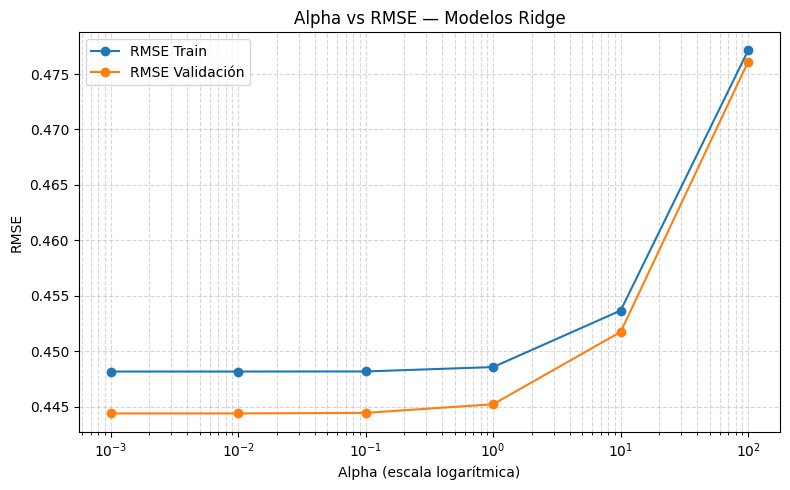

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(resultados_ridge_df['alpha'], resultados_ridge_df['RMSE Train'], marker='o', label='RMSE Train')
plt.plot(resultados_ridge_df['alpha'], resultados_ridge_df['RMSE Val'], marker='o', label='RMSE Validación')
plt.xscale('log')
plt.xlabel('Alpha (escala logarítmica)')
plt.ylabel('RMSE')
plt.title('Alpha vs RMSE — Modelos Ridge')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**3.** ¿Cuál es el mejor alpha?

El mejor alpha es 0.001, con un RMSE de validación de 0.4444. Sin embargo, esto indica que la regularización no está ayudando en este caso: los alphas 0.001, 0.01 y 0.1 producen exactamente el mismo RMSE que la regresión lineal sin regularización. Esto sugiere que el modelo no presenta un problema de sobreajuste significativo con estas features, y Ridge no aporta mejora adicional sobre la regresión lineal estándar.

**4.** Entrena el modelo final (con el mejor alpha) usando train + val

In [36]:
best_alpha = resultados_ridge_df.loc[resultados_ridge_df['RMSE Val'].idxmin(), 'alpha']

X_trainval = train_val3[feature_cols]
y_trainval = train_val3['msrp']
X_test3 = test3[feature_cols]
y_test3 = test3['msrp']

modelo_final = Ridge(alpha=best_alpha)
modelo_final.fit(X_trainval, y_trainval)

rmse_test_final = root_mean_squared_error(y_test3, modelo_final.predict(X_test3))

**5.** Reporta el RMSE en test

In [37]:
print(f"Alpha usado: {best_alpha}")
print(f"Tamaño train+val: {len(X_trainval)} muestras")
print(f"RMSE Test (modelo final): {rmse_test_final:.4f}")

Alpha usado: 0.001
Tamaño train+val: 9467 muestras
RMSE Test (modelo final): 0.4474


## Ejercicio 5: Comparación final

In [39]:
best_alpha = resultados_ridge_df.loc[resultados_ridge_df['RMSE Val'].idxmin(), 'alpha']
rmse_ridge_val = resultados_ridge_df['RMSE Val'].min()

print("=" * 55)
print(f"{'Tabla resumen — RMSE en validación':^55}")
print("=" * 55)
print(f"{'Modelo':<25} {'Features':<15} {'RMSE val':>10}")
print("-" * 55)
print(f"{'Baseline (2 features)':<25} {'year, hp':<15} {rmse_val:>10.4f}")
print(f"{'Lineal (5 features)':<25} {'5 features':<15} {rmse_val2:>10.4f}")
print(f"{'Lineal (todas)':<25} {'51 features':<15} {rmse_val3:>10.4f}")
print(f"{'Ridge (alpha=' + str(best_alpha) + ')':<25} {'51 features':<15} {rmse_ridge_val:>10.4f}")
print("=" * 55)

          Tabla resumen — RMSE en validación           
Modelo                    Features          RMSE val
-------------------------------------------------------
Baseline (2 features)     year, hp            0.5174
Lineal (5 features)       5 features          0.5133
Lineal (todas)            51 features         0.4444
Ridge (alpha=0.001)       51 features         0.4444
